# examine [OII] emission line SNR 
With the ultimate goal of estimating the redshift success rate with 15min exposure times. 

In [1]:
import numpy as np 
from astropy.table import Table

In [2]:
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

# read catalog

In [3]:
# OII table from Jingjing's google drive 
#oii = Table.read('/Users/hahnchanghoon/data/pfs/lam1d_oii_table_flux_sn_full_v2.fits')
oii = Table.read('lam1d_s25a_matched_run21_run22_v4.fits')

In [4]:
# compile HSC photometry
# extinction corrected magnitudes 
g_mag = oii['g_cmodel_mag'] - oii['a_g']
r_mag = oii['r_cmodel_mag'] - oii['a_r']
i_mag = oii['i_cmodel_mag'] - oii['a_i']
z_mag = oii['z_cmodel_mag'] - oii['a_z']

In [5]:
zsucc = ((oii['probaGalaxy'] > 0.99) & 
         (oii['redshiftProba'] > 0.99) & 
         (oii['redshiftError'] < 0.01))
print('overall z-success %.3f' % np.mean(zsucc))

overall z-success 0.640


In [6]:
has_lam = zsucc & (oii['redshift'] < 1.6) & (oii['spectrograph'] != 2)
has_vi = (oii['z_vi'] > 0) & (oii['spectrograph'] != 2)
# exclude spectrograph 2 which has NIR detector problems

# compare SNR measurements

In [11]:
oii_snr0 = np.sqrt(oii['oii_sn2_MT'] / oii['oii_sn_pixel_num_MT']) # only defined for zsucc & (oii['redshift'] < 1.6)
oii_snr1 = oii['oii_flux_MT'] / oii['oii_noise_MT']
oii_snr2 = np.sqrt(oii['oii sn2'])

/var/folders/w7/p2lcz8lj0m39n1ywl2_s0_j40000gp/T/ipykernel_66508/1216089803.py:3: RuntimeWarning: invalid value encountered in sqrt
  oii_snr2 = np.sqrt(oii['oii sn2'])


(0.0, 50.0)

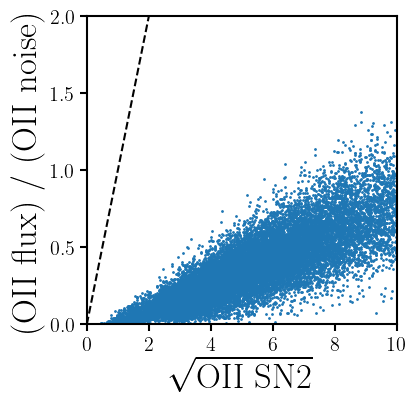

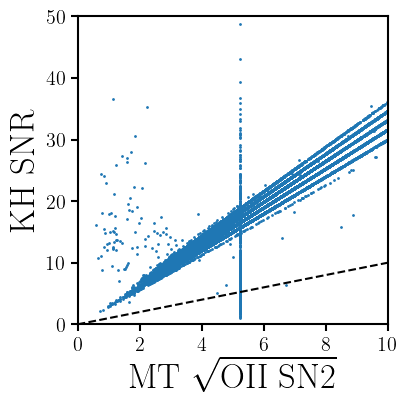

In [13]:
fig = plt.figure(figsize=(4,4))
sub = fig.add_subplot(111)
sub.scatter(oii_snr0[has_lam], oii_snr1[has_lam], c='C0', s=1)
sub.plot([0, 100.], [0, 100], c='k', ls='--')
sub.set_xlabel(r'$\sqrt{\rm OII~SN2}$', fontsize=25)
sub.set_xlim(0., 10)
sub.set_ylabel(r'(OII flux) / (OII noise)', fontsize=25)
sub.set_ylim(0., 2)

fig = plt.figure(figsize=(4,4))
sub = fig.add_subplot(111)
sub.scatter(oii_snr0[has_lam], oii_snr2[has_lam], c='C0', s=1)
sub.plot([0, 100.], [0, 100], c='k', ls='--')
sub.set_xlabel(r'MT $\sqrt{\rm OII~SN2}$', fontsize=25)
sub.set_xlim(0., 10)
sub.set_ylabel(r'KH SNR', fontsize=25)
sub.set_ylim(0., 50)

/var/folders/w7/p2lcz8lj0m39n1ywl2_s0_j40000gp/T/ipykernel_66508/137623824.py:19: RuntimeWarning: invalid value encountered in log10
  hb = sub.scatter(oii['redshift'][has_lam], np.log10(oii_snr1[has_lam]),


Text(0, 0.5, 'exposure time (minutes)')

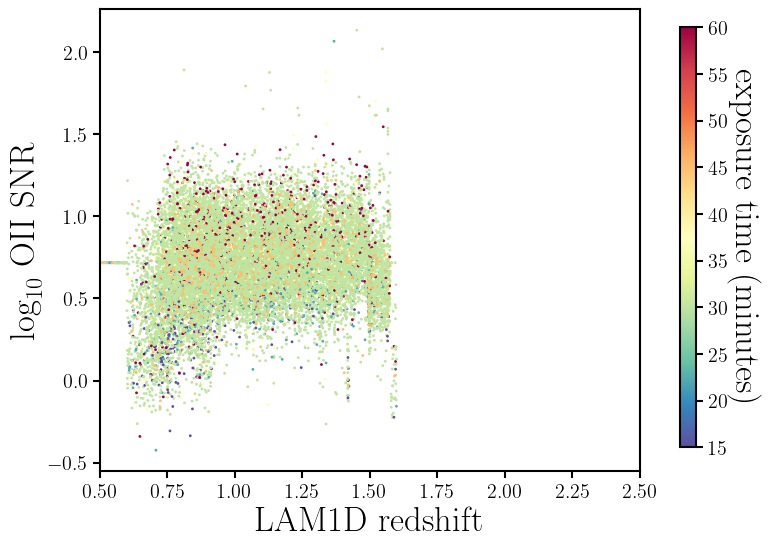

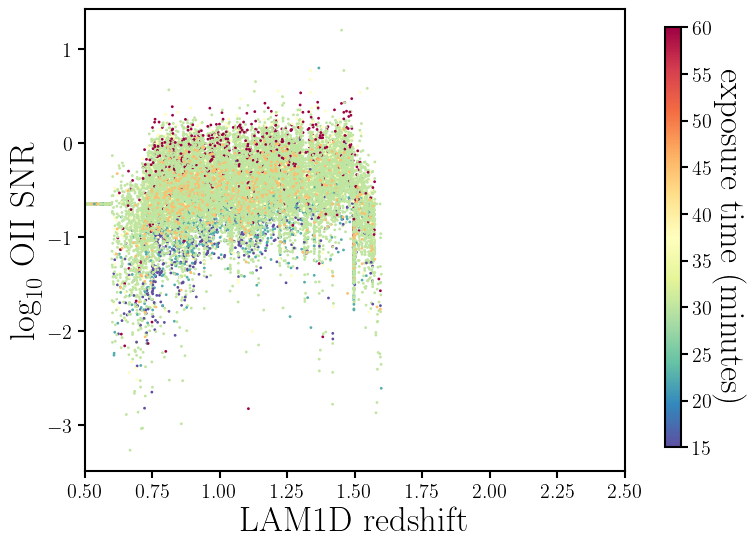

In [14]:
fig = plt.figure(figsize=(8,6))
sub = fig.add_subplot(111)
hb = sub.scatter(oii['redshift'][has_lam], np.log10(oii_snr0[has_lam]), 
                 c=oii['t_exp_total'][has_lam]/60., s=1, vmin=15., vmax=60, cmap='Spectral_r')

#sub.text(2.4, 1.5, 'Run 21 + Run 22', ha='right', va='top', fontsize=25)
sub.set_xlabel('LAM1D redshift', fontsize=25)
sub.set_xlim(0.5, 2.5)
sub.set_ylabel(r'$\log_{10}$ OII SNR', fontsize=25)

fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'exposure time (minutes)', labelpad=25, fontsize=25, rotation=270)

fig = plt.figure(figsize=(8,6))
sub = fig.add_subplot(111)
hb = sub.scatter(oii['redshift'][has_lam], np.log10(oii_snr1[has_lam]), 
                 c=oii['t_exp_total'][has_lam]/60., s=1, vmin=15., vmax=60, cmap='Spectral_r')

#sub.text(2.4, 1.5, 'Run 21 + Run 22', ha='right', va='top', fontsize=25)
sub.set_xlabel('LAM1D redshift', fontsize=25)
sub.set_xlim(0.5, 2.5)
sub.set_ylabel(r'$\log_{10}$ OII SNR', fontsize=25)

fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'exposure time (minutes)', labelpad=25, fontsize=25, rotation=270)

Text(0, 0.5, 'exposure time (minutes)')

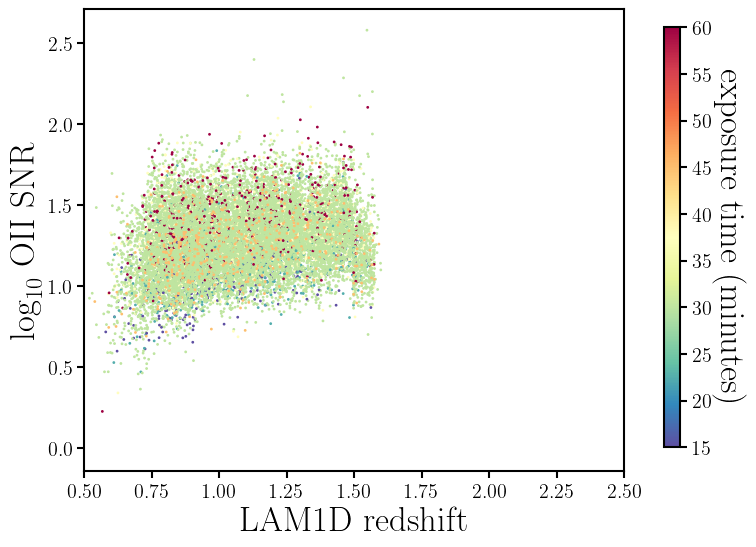

In [15]:
fig = plt.figure(figsize=(8,6))
sub = fig.add_subplot(111)
hb = sub.scatter(oii['redshift'][has_lam], np.log10(oii_snr2[has_lam]), 
                 c=oii['t_exp_total'][has_lam]/60., s=1, vmin=15., vmax=60, cmap='Spectral_r')

#sub.text(2.4, 1.5, 'Run 21 + Run 22', ha='right', va='top', fontsize=25)
sub.set_xlabel('LAM1D redshift', fontsize=25)
sub.set_xlim(0.5, 2.5)
sub.set_ylabel(r'$\log_{10}$ OII SNR', fontsize=25)

fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'exposure time (minutes)', labelpad=25, fontsize=25, rotation=270)

/var/folders/w7/p2lcz8lj0m39n1ywl2_s0_j40000gp/T/ipykernel_66508/357571543.py:3: RuntimeWarning: invalid value encountered in log10
  hb = sub.scatter(oii['z_vi'][has_lam & has_vi], np.log10(oii_snr1[has_lam & has_vi]),


Text(0, 0.5, 'exposure time (minutes)')

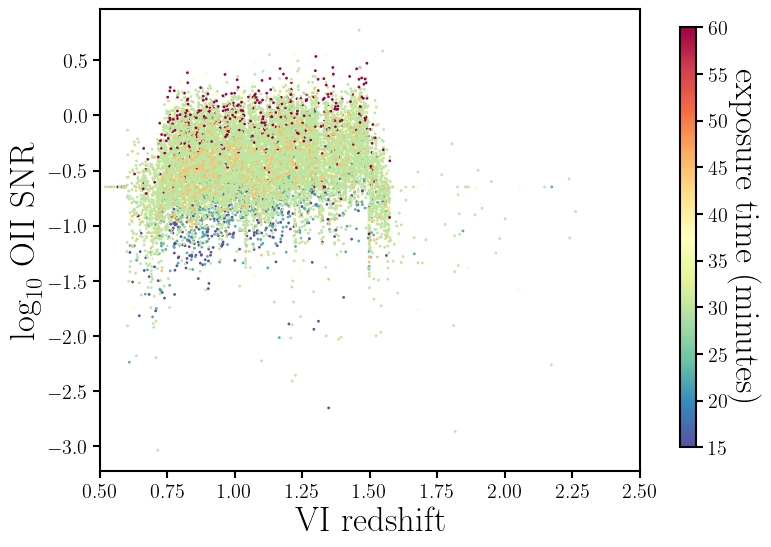

In [16]:
fig = plt.figure(figsize=(8,6))
sub = fig.add_subplot(111)
hb = sub.scatter(oii['z_vi'][has_lam & has_vi], np.log10(oii_snr1[has_lam & has_vi]), 
                 c=oii['t_exp_total'][has_lam & has_vi]/60., s=1, vmin=15., vmax=60, cmap='Spectral_r')
sub.set_xlabel('VI redshift', fontsize=25)
sub.set_xlim(0.5, 2.5)
sub.set_ylabel(r'$\log_{10}$ OII SNR', fontsize=25)

fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'exposure time (minutes)', labelpad=25, fontsize=25, rotation=270)

Text(0, 0.5, 'exposure time (minutes)')

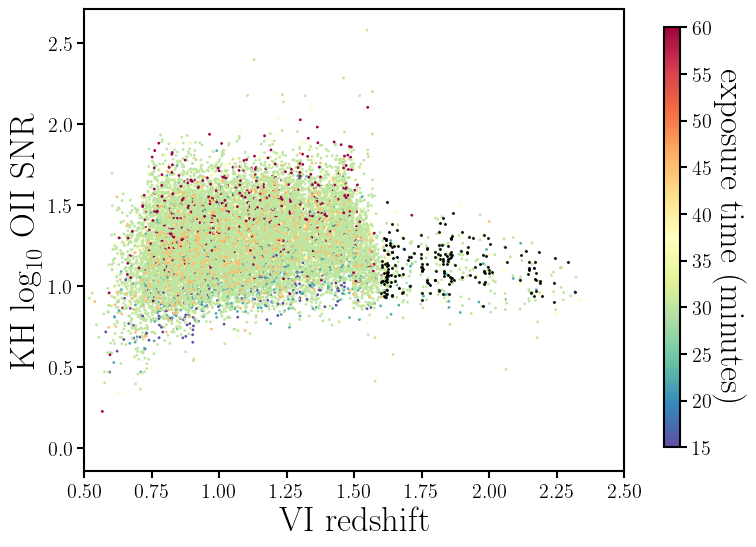

In [21]:
fig = plt.figure(figsize=(8,6))
sub = fig.add_subplot(111)
hb = sub.scatter(oii['z_vi'][has_vi], np.log10(oii_snr2[has_vi]), 
                 c=oii['t_exp_total'][has_vi]/60., s=1, vmin=15., vmax=60, cmap='Spectral_r')

good_vi = (oii['score_best4'] > 3)
sub.scatter(oii['z_vi'][has_vi & good_vi], np.log10(oii_snr2[has_vi & good_vi]), c='k', s=1)

#sub.text(2.4, 1.5, 'Run 21 + Run 22', ha='right', va='top', fontsize=25)
sub.set_xlabel('VI redshift', fontsize=25)
sub.set_xlim(0.5, 2.5)
sub.set_ylabel(r'KH $\log_{10}$ OII SNR', fontsize=25)

fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'exposure time (minutes)', labelpad=25, fontsize=25, rotation=270)

# OII SNR for $z$-successs

1.2145542
1.2685913
1.3144308
1.3397639


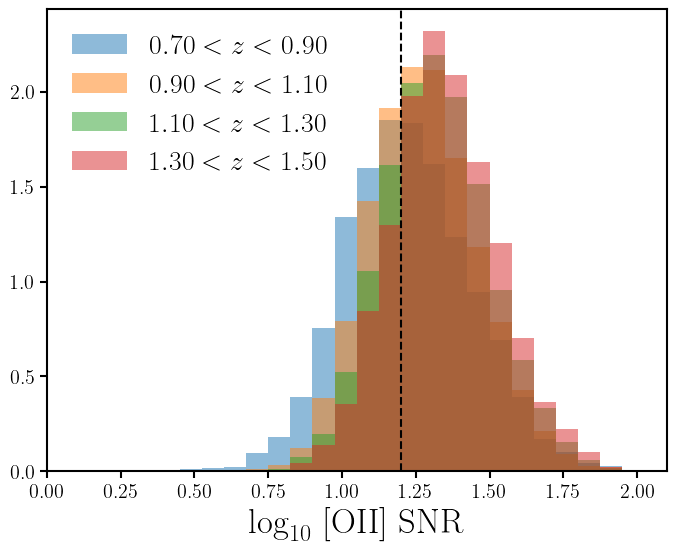

In [35]:
fig = plt.figure(figsize=(8,6))
sub = fig.add_subplot(111)
for _z in [0.8, 1., 1.2, 1.4]: 
    _zslice = (oii['z_vi'] > _z - 0.1) & (oii['z_vi'] < _z + 0.1) & has_vi & has_lam
    _ = sub.hist(np.log10(oii_snr2)[_zslice], range=(0, 3), bins=40, alpha=0.5, density=True, 
                 label=r'$%.2f < z < %.2f$' % (_z - 0.1, _z+0.1))
    print(np.median(np.log10(oii_snr2)[_zslice]))
sub.axvline(1.2, color='k', linestyle='--')
sub.set_xlabel(r'$\log_{10}$ [OII] SNR', fontsize=25)
sub.set_xlim(0., 2.1)
sub.legend(loc='upper left', fontsize=20)

1.0957665
1.0941187
1.120748
1.0320742
1.0339731
1.0883964


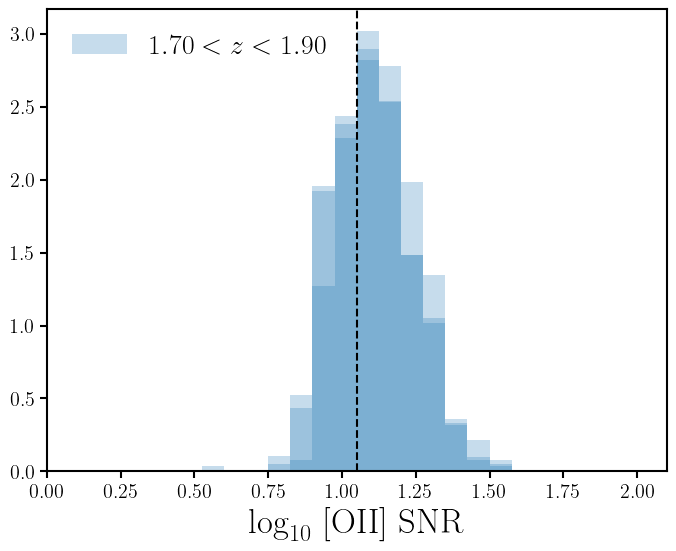

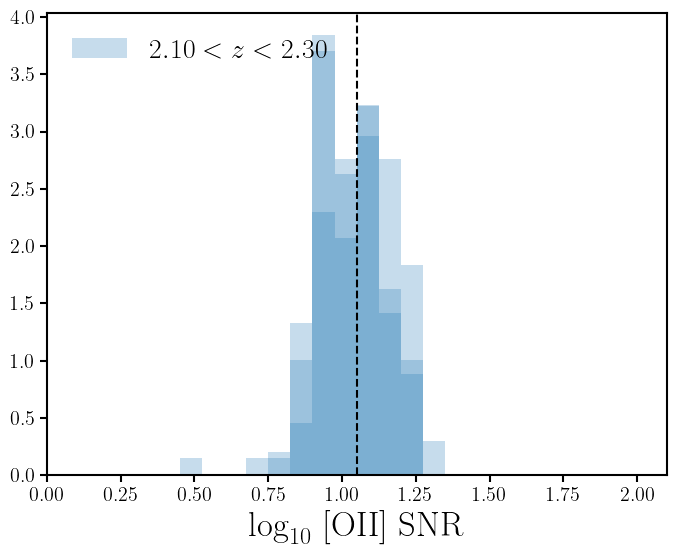

In [38]:
fig = plt.figure(figsize=(8,6))
sub = fig.add_subplot(111)
for i, _z in enumerate([1.8]): 
    _zslice = (oii['z_vi'] > _z - 0.2) & (oii['z_vi'] < _z + 0.2) & has_vi
    _ = sub.hist(np.log10(oii_snr2)[_zslice], range=(0, 3), bins=40, alpha=0.25, density=True, color='C%i' % i,
                 label=r'$%.2f < z < %.2f$' % (_z - 0.1, _z+0.1))
    print(np.median(np.log10(oii_snr2)[_zslice]))
    
    _zslice = (oii['z_vi'] > _z - 0.2) & (oii['z_vi'] < _z + 0.2) & has_vi & (oii['score_best4'] > 2)
    _ = sub.hist(np.log10(oii_snr2)[_zslice], range=(0, 3), bins=40, alpha=0.25, density=True, color='C%i' % i)
    print(np.median(np.log10(oii_snr2)[_zslice]))

    _zslice = (oii['z_vi'] > _z - 0.2) & (oii['z_vi'] < _z + 0.2) & has_vi & (oii['score_best4'] > 3)
    _ = sub.hist(np.log10(oii_snr2)[_zslice], range=(0, 3), bins=40, alpha=0.25, density=True, color='C%i' % i)
    print(np.median(np.log10(oii_snr2)[_zslice]))

sub.axvline(1.05, color='k', linestyle='--')
sub.set_xlabel(r'$\log_{10}$ [OII] SNR', fontsize=25)
sub.set_xlim(0., 2.1)
sub.legend(loc='upper left', fontsize=20)

fig = plt.figure(figsize=(8,6))
sub = fig.add_subplot(111)
for i, _z in enumerate([2.2]): 
    _zslice = (oii['z_vi'] > _z - 0.2) & (oii['z_vi'] < _z + 0.2) & has_vi
    _ = sub.hist(np.log10(oii_snr2)[_zslice], range=(0, 3), bins=40, alpha=0.25, density=True, color='C%i' % i,
                 label=r'$%.2f < z < %.2f$' % (_z - 0.1, _z+0.1))
    print(np.median(np.log10(oii_snr2)[_zslice]))
    
    _zslice = (oii['z_vi'] > _z - 0.2) & (oii['z_vi'] < _z + 0.2) & has_vi & (oii['score_best4'] > 2)
    _ = sub.hist(np.log10(oii_snr2)[_zslice], range=(0, 3), bins=40, alpha=0.25, density=True, color='C%i' % i)
    print(np.median(np.log10(oii_snr2)[_zslice]))

    _zslice = (oii['z_vi'] > _z - 0.2) & (oii['z_vi'] < _z + 0.2) & has_vi & (oii['score_best4'] > 3)
    _ = sub.hist(np.log10(oii_snr2)[_zslice], range=(0, 3), bins=40, alpha=0.25, density=True, color='C%i' % i)
    print(np.median(np.log10(oii_snr2)[_zslice]))

sub.axvline(1.05, color='k', linestyle='--')
sub.set_xlabel(r'$\log_{10}$ [OII] SNR', fontsize=25)
sub.set_xlim(0., 2.1)
sub.legend(loc='upper left', fontsize=20)


# How does the $z$ success rate shift if we *naively* scale the exposure times down

Text(0, 0.5, '$\\log_{10}$ OII SNR')

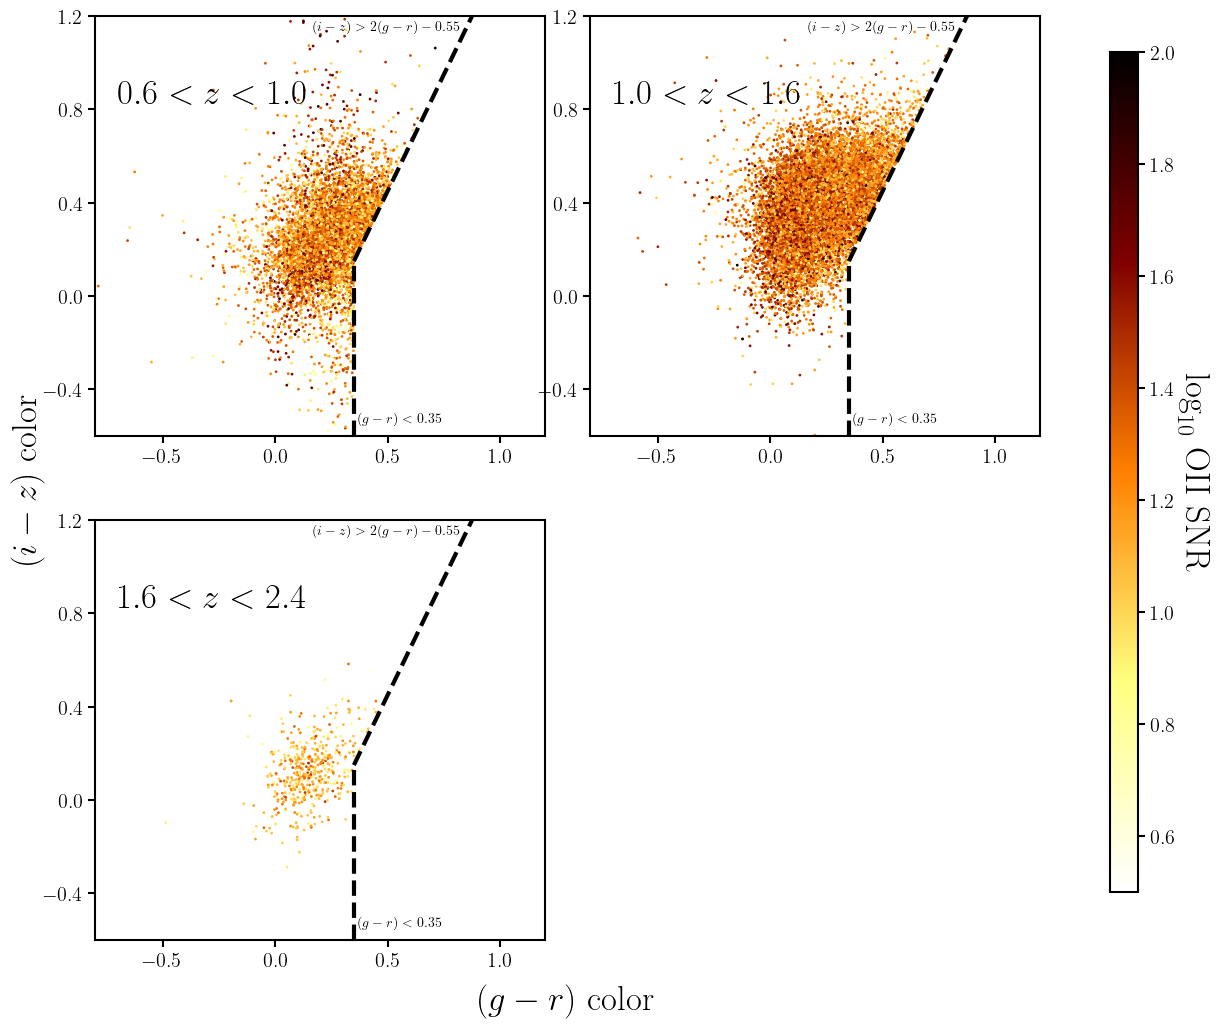

In [60]:
fig = plt.figure(figsize=(14, 12))
for i in range(3): 
    sub = fig.add_subplot(2,2,i+1)

    zlim = ((oii['z_vi'] > [0.6, 1., 1.6][i]) & (oii['z_vi'] < [1., 1.6, 2.4][i]) & has_vi)

    hb = sub.scatter(
        (g_mag - r_mag)[zlim], # (g-r)
        (i_mag - z_mag)[zlim], # (i-z)
        c=np.log10(oii_snr2[zlim]), s=1, vmin=0.5, vmax=2, cmap='afmhot_r')

    sub.text(0.05, 0.85, r'$%.1f < z < %.1f$' % ([0.6, 1., 1.6][i], [1., 1.6, 2.4][i]), ha='left', va='top', transform=sub.transAxes, fontsize=25)
    
    sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
    sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)
    
    sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
    sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
    sub.set_xlim(-0.8, 1.2)
    sub.set_ylim(-0.6, 1.2)
    sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'$\log_{10}$ OII SNR', labelpad=25, fontsize=25, rotation=270)

In [61]:
# scale OII SNR down based on exposure time
oii_snr_scaled = oii_snr2 / np.sqrt(oii['t_exp_total'] / 900.)

Text(0, 0.5, 'exposure time (minutes)')

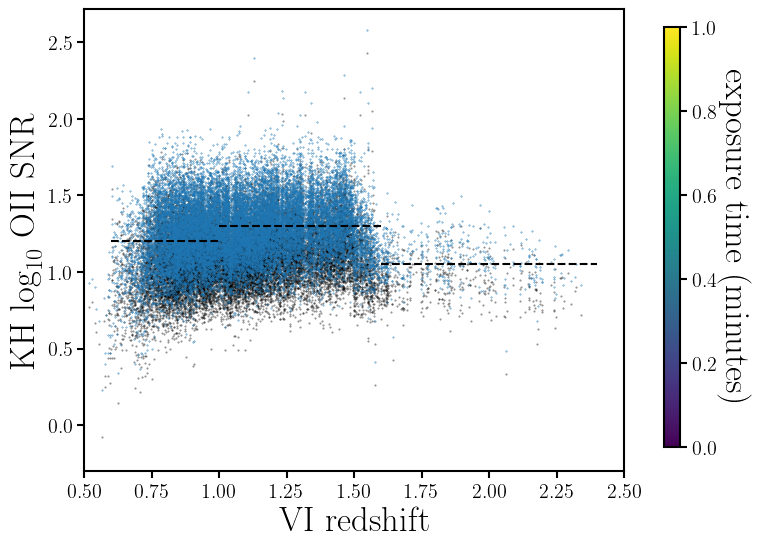

In [68]:
fig = plt.figure(figsize=(8,6))
sub = fig.add_subplot(111)
hb = sub.scatter(oii['z_vi'][has_vi], np.log10(oii_snr_scaled[has_vi]), 
                 c='k', s=0.2, alpha=0.5)
hb = sub.scatter(oii['z_vi'][has_vi], np.log10(oii_snr2[has_vi]), 
                 c='C0', s=0.1)

sub.plot([0.6, 1.], [1.2, 1.2], c='k', ls='--') 
sub.plot([1., 1.6], [1.3, 1.3], c='k', ls='--') 
sub.plot([1.6, 2.4], [1.05, 1.05], c='k', ls='--') 

#sub.text(2.4, 1.5, 'Run 21 + Run 22', ha='right', va='top', fontsize=25)
sub.set_xlabel('VI redshift', fontsize=25)
sub.set_xlim(0.5, 2.5)
sub.set_ylabel(r'KH $\log_{10}$ OII SNR', fontsize=25)

fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'exposure time (minutes)', labelpad=25, fontsize=25, rotation=270)

0.543793536599292
0.3964338781575037
0.4148471615720524


Text(0, 0.5, '$N_{\\rm z}$(15min)/$N_{\\rm z}$(30min)')

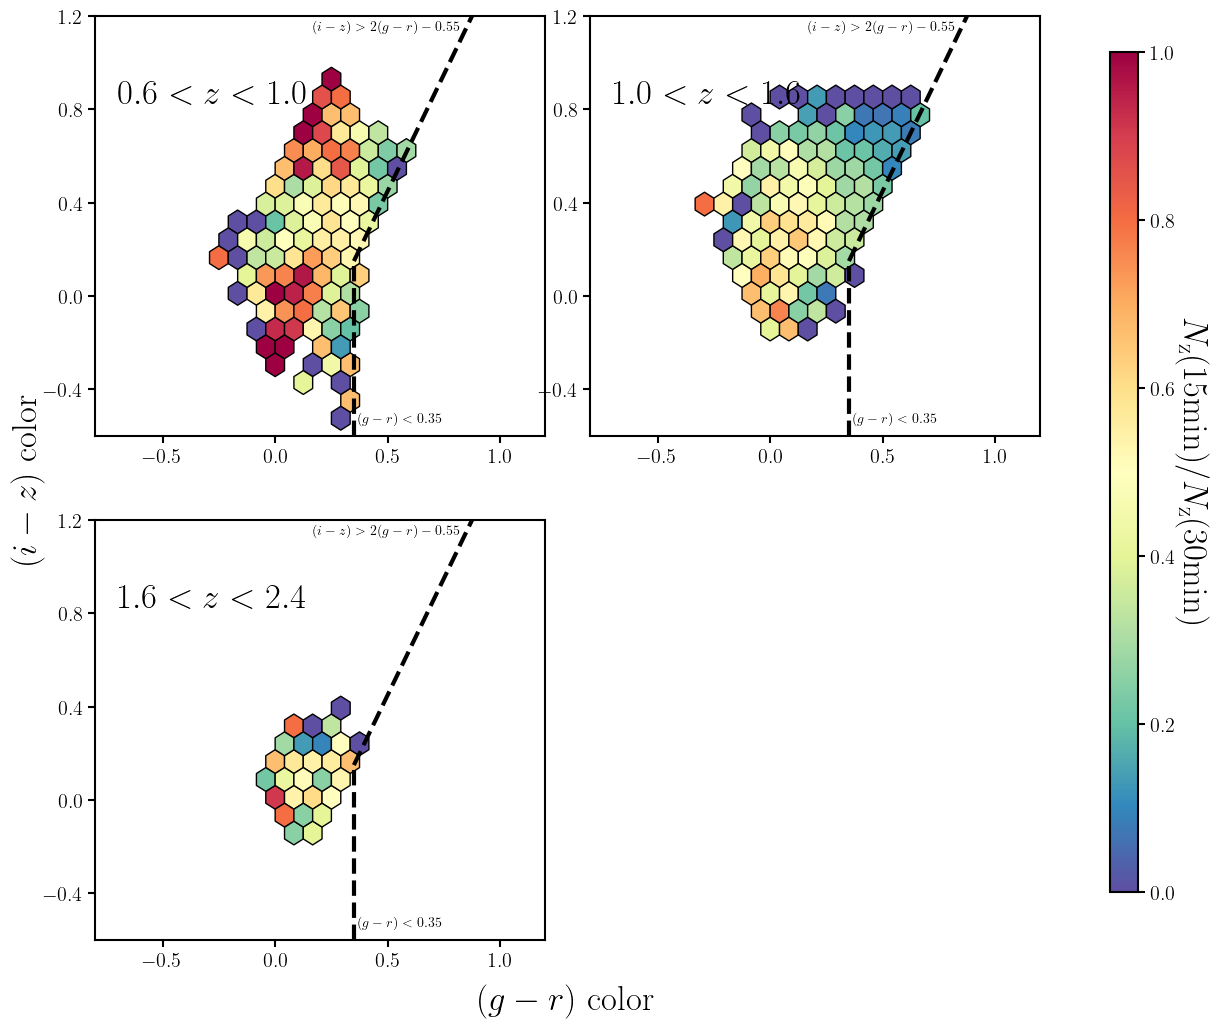

In [66]:
fig = plt.figure(figsize=(14, 12))
for i in range(3): 
    sub = fig.add_subplot(2,2,i+1)

    zlim = ((oii['z_vi'] > [0.6, 1., 1.6][i]) & (oii['z_vi'] < [1., 1.6, 2.4][i]))# & best_lam & ~mask_oii)

    snr_cut = (oii_snr_scaled > [10**1.2, 10**1.3, 10**1.05][i])
    print(2*np.mean(snr_cut.astype(float)[zlim & has_vi]))
    hb = sub.hexbin(
        (g_mag - r_mag)[zlim & has_vi], # (g-r)
        (i_mag - z_mag)[zlim & has_vi], # (i-z)
        C=snr_cut.astype(float)[zlim & has_vi], 
        edgecolors='k', linewidth=1., reduce_C_function=lambda x: 2 * np.mean(x), 
        extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0., vmax=1., mincnt=5, cmap='Spectral_r')
    
    sub.text(0.05, 0.85, r'$%.1f < z < %.1f$' % ([0.6, 1., 1.6][i], [1., 1.6, 2.4][i]), ha='left', va='top', transform=sub.transAxes, fontsize=25)
    
    sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
    sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)
    
    sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
    sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
    sub.set_xlim(-0.8, 1.2)
    sub.set_ylim(-0.6, 1.2)
    sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'$N_{\rm z}$(15min)/$N_{\rm z}$(30min)', labelpad=25, fontsize=25, rotation=270)